# Breast Cancer Histopathology Dataset Exploration

## Objective

The objective of this notebook is to explore the BreakHis dataset before building a deep learning pipeline.

The analysis includes:

- Understanding the folder structure
- Counting images
- Exploring class distribution
- Exploring magnification levels
- Inspecting image dimensions
- Detecting corrupted images
- Displaying representative samples

This notebook serves as the foundation for the preprocessing and model development pipeline.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
from pathlib import Path

import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [3]:
from pathlib import Path


# Current notebook location
NOTEBOOK_DIR = Path.cwd()

# Project root directory
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Dataset paths
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

DATASET_DIR = (
    RAW_DATA_DIR
    / "BreaKHis_v1"
    / "BreaKHis_v1"
    / "histology_slides"
    / "breast"
)

FOLDS_FILE = RAW_DATA_DIR / "Folds.csv"

print("Project Root :", PROJECT_ROOT)
print("Dataset Path :", DATASET_DIR)
print("Folds File   :", FOLDS_FILE)

Project Root : c:\Users\srush\OneDrive\Desktop\Projects\Breast Cancer Histopathology Detection
Dataset Path : c:\Users\srush\OneDrive\Desktop\Projects\Breast Cancer Histopathology Detection\data\raw\BreaKHis_v1\BreaKHis_v1\histology_slides\breast
Folds File   : c:\Users\srush\OneDrive\Desktop\Projects\Breast Cancer Histopathology Detection\data\raw\Folds.csv


In [4]:
assert PROJECT_ROOT.exists(), "Project root not found!"
assert DATA_DIR.exists(), "Data directory not found!"
assert RAW_DATA_DIR.exists(), "Raw data directory not found!"
assert DATASET_DIR.exists(), "Dataset directory not found!"
assert FOLDS_FILE.exists(), "Folds.csv not found!"

print("All required paths verified successfully!")

All required paths verified successfully!


In [5]:
for i in DATASET_DIR.iterdir():
    print(i.name)

benign
count_files.sh
malignant
README.txt


In [6]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

image_paths = [
    path
    for path in DATASET_DIR.rglob("*")
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

print(f"Total Images: {len(image_paths)}")

Total Images: 7909


In [7]:
class_counts = {}

for class_dir in DATASET_DIR.iterdir():
    if class_dir.is_dir():
        image_count = sum(
            1
            for image in class_dir.rglob("*")
            if image.suffix.lower() in IMAGE_EXTENSIONS
        )
        class_counts[class_dir.name] = image_count

class_counts

{'benign': 2480, 'malignant': 5429}

In [8]:
pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Number of Images"]
)

,Class,Number of Images
0,benign,2480
1,malignant,5429


### Is the dataset balanced, or does one class have significantly more images than the other?

In [9]:
class_distribution = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Number of Images"]
)

class_distribution

,Class,Number of Images
0,benign,2480
1,malignant,5429


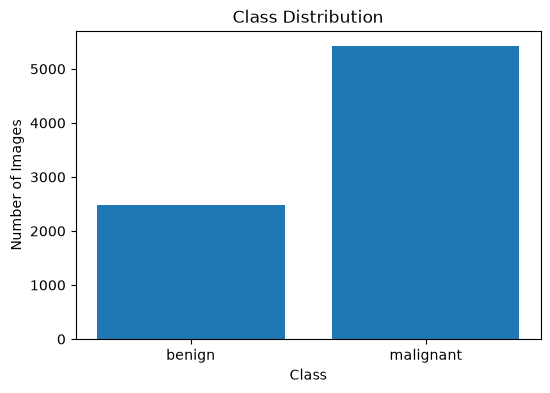

In [10]:
plt.figure(figsize=(6, 4))

plt.bar(
    class_distribution["Class"],
    class_distribution["Number of Images"]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

Observation: The dataset contains both benign and malignant histopathology images. The malignant class contains more samples than the benign class, indicating a moderate class imbalance. This should be considered during model training and evaluation.

In [11]:
for item in (DATASET_DIR / "benign").iterdir():
    print(item.name)

adenosis.stat.txt
fibroadenoma.stat.txt
phyllodes_tumor.stat.txt
process_db_stat.py
README_B.txt
SOB
tubular_adenoma.stat.txt


In [12]:
for item in (DATASET_DIR / "benign" / "SOB" / "adenosis").iterdir():
    print(item.name)

SOB_B_A_14-22549AB
SOB_B_A_14-22549CD
SOB_B_A_14-22549G
SOB_B_A_14-29960CD


In [13]:
for item in (DATASET_DIR / "benign" / "SOB").iterdir():
    print(item.name)

adenosis
fibroadenoma
phyllodes_tumor
tubular_adenoma


The BreakHis dataset is hierarchically organized. The top level separates benign and malignant tumors. Each class is further divided into histopathological subtypes, and the actual image files are stored deeper in the directory structure. This organization will require a custom data-loading pipeline rather than a simple flat directory loader.

In [14]:
for item in (DATASET_DIR / "benign" / "SOB" / "adenosis" / "SOB_B_A_14-22549AB").iterdir():
    print(item.name)

100X
200X
400X
40X


In [15]:
from src.data.parser import BreakHisParser

parser = BreakHisParser(DATASET_DIR)

metadata = parser.build_metadata()

metadata.head()

,image_path,class,subtype,patient_id,magnification
0,C:\Users\srush\OneDrive\Desktop\Projects\Breas...,benign,adenosis,SOB_B_A_14-22549AB,100X
1,C:\Users\srush\OneDrive\Desktop\Projects\Breas...,benign,adenosis,SOB_B_A_14-22549AB,100X
2,C:\Users\srush\OneDrive\Desktop\Projects\Breas...,benign,adenosis,SOB_B_A_14-22549AB,100X
3,C:\Users\srush\OneDrive\Desktop\Projects\Breas...,benign,adenosis,SOB_B_A_14-22549AB,100X
4,C:\Users\srush\OneDrive\Desktop\Projects\Breas...,benign,adenosis,SOB_B_A_14-22549AB,100X


In [16]:
metadata.shape

(7909, 5)

In [17]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 7909 entries, 0 to 7908
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   image_path     7909 non-null   str  
 1   class          7909 non-null   str  
 2   subtype        7909 non-null   str  
 3   patient_id     7909 non-null   str  
 4   magnification  7909 non-null   str  
dtypes: str(5)
memory usage: 2.3 MB


In [18]:
metadata["class"].value_counts()

class
malignant    5429
benign       2480
Name: count, dtype: int64

In [19]:
metadata["subtype"].value_counts()

subtype
ductal_carcinoma       3451
fibroadenoma           1014
mucinous_carcinoma      792
lobular_carcinoma       626
tubular_adenoma         569
papillary_carcinoma     560
phyllodes_tumor         453
adenosis                444
Name: count, dtype: int64

In [20]:
metadata["magnification"].value_counts()

magnification
100X    2081
200X    2013
40X     1995
400X    1820
Name: count, dtype: int64

In [21]:
metadata.sample(5)

,image_path,class,subtype,patient_id,magnification
7187,C:\Users\srush\OneDrive\Desktop\Projects\Breas...,malignant,mucinous_carcinoma,SOB_M_MC_14-18842D,40X
1888,C:\Users\srush\OneDrive\Desktop\Projects\Breas...,benign,phyllodes_tumor,SOB_B_PT_14-29315EF,400X
3735,C:\Users\srush\OneDrive\Desktop\Projects\Breas...,malignant,ductal_carcinoma,SOB_M_DC_14-16188,200X
3874,C:\Users\srush\OneDrive\Desktop\Projects\Breas...,malignant,ductal_carcinoma,SOB_M_DC_14-16448,200X
1427,C:\Users\srush\OneDrive\Desktop\Projects\Breas...,benign,fibroadenoma,SOB_B_F_14-9133,400X


In [22]:
metadata.to_csv(
    PROJECT_ROOT / "data" / "processed" / "metadata.csv",
    index=False
)

In [23]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.dataset import BreakHisDataset
dataset = BreakHisDataset(metadata)

dataset[0]

In [24]:
import sys
import torch

print(sys.executable)
print(sys.version)
print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

c:\Users\srush\OneDrive\Desktop\Projects\Breast Cancer Histopathology Detection\.venv\Scripts\python.exe
3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
2.6.0+cu124
True
NVIDIA GeForce RTX 3050 Laptop GPU
